# Sarah Cheulkar

## 23102C0060
## Assignment 2 — R Programming
## Module 1 & 2: Data Cleaning and Missing Data Handling

**Part 1:** Control Flow for Data Cleaning : UCI Heart Disease Dataset  
**Part 2:** Advanced Missing Data Handling : UCI Adult/Census Income Dataset



## Part 1 — Control Flow for Data Cleaning


In [1]:
# Load required packages
options(repos = c(CRAN = "https://cloud.r-project.org"))

required_packages <- c("naniar", "skimr", "ggplot2")

for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, quiet = TRUE)
  }
}

library(naniar)
library(skimr)
library(ggplot2)


also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




In [2]:
# Load UCI Heart Disease dataset
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

heart_data <- read.csv(
  url,
  header = FALSE,
  na.strings = "?"
)

colnames(heart_data) <- c(
  "age", "sex", "cp", "trestbps", "chol",
  "fbs", "restecg", "thalach", "exang",
  "oldpeak", "slope", "ca", "thal", "num"
)

heart_data$trestbps <- as.numeric(heart_data$trestbps)
heart_data$chol <- as.numeric(heart_data$chol)

head(heart_data)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


In [3]:
# Basic dataset inspection
str(heart_data)
summary(heart_data)


'data.frame':	303 obs. of  14 variables:
 $ age     : num  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : num  1 1 1 1 0 1 0 0 1 1 ...
 $ cp      : num  1 4 4 3 2 2 4 4 4 4 ...
 $ trestbps: num  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : num  1 0 0 0 0 0 0 0 0 1 ...
 $ restecg : num  2 2 2 0 2 0 2 0 2 2 ...
 $ thalach : num  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : num  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : num  3 2 2 3 1 1 3 1 2 3 ...
 $ ca      : num  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : num  6 3 7 3 3 3 3 3 7 7 ...
 $ num     : int  0 2 1 0 0 0 3 0 2 1 ...


      age             sex               cp           trestbps    
 Min.   :29.00   Min.   :0.0000   Min.   :1.000   Min.   : 94.0  
 1st Qu.:48.00   1st Qu.:0.0000   1st Qu.:3.000   1st Qu.:120.0  
 Median :56.00   Median :1.0000   Median :3.000   Median :130.0  
 Mean   :54.44   Mean   :0.6799   Mean   :3.158   Mean   :131.7  
 3rd Qu.:61.00   3rd Qu.:1.0000   3rd Qu.:4.000   3rd Qu.:140.0  
 Max.   :77.00   Max.   :1.0000   Max.   :4.000   Max.   :200.0  
                                                                 
      chol            fbs            restecg          thalach     
 Min.   :126.0   Min.   :0.0000   Min.   :0.0000   Min.   : 71.0  
 1st Qu.:211.0   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:133.5  
 Median :241.0   Median :0.0000   Median :1.0000   Median :153.0  
 Mean   :246.7   Mean   :0.1485   Mean   :0.9901   Mean   :149.6  
 3rd Qu.:275.0   3rd Qu.:0.0000   3rd Qu.:2.0000   3rd Qu.:166.0  
 Max.   :564.0   Max.   :1.0000   Max.   :2.0000   Max.   :202.0  
   

In [4]:
# Deliberately introduce data-entry problems as required
heart_data$trestbps[1] <- -20
heart_data$trestbps[2] <- NA
heart_data$trestbps[3] <- 320
heart_data$trestbps[4] <- -10
heart_data$trestbps[5] <- 350

heart_data$trestbps[1:10]


[1] -20  NA 320 -10 350 120 140 120 130 140

### Custom BP-cleaning function


In [5]:
clean_bp <- function(bp) {
  if (is.na(bp)) {
    return(NA_real_)
  } else if (bp < 0) {
    return(NA_real_)
  } else if (bp > 250) {
    return(250)
  } else {
    return(bp)
  }
}

# Test the custom function
clean_bp(-20)
clean_bp(320)
clean_bp(120)
clean_bp(NA)


[1] NA

[1] 250

[1] 120

[1] NA

In [6]:
# Apply custom function to all BP values
heart_data$trestbps_clean <- sapply(
  heart_data$trestbps,
  clean_bp
)

head(heart_data[, c("trestbps", "trestbps_clean")], 10)


,trestbps,trestbps_clean
,<dbl>,<dbl>
1,-20,NA
2,NA,NA
3,320,250
4,-10,NA
5,350,250
6,120,120
7,140,140
8,120,120
9,130,130


### Error handling with

In [7]:
safe_mean_bp <- function(bp) {
  tryCatch(
    {
      if (any(is.na(bp))) {
        warning("Missing BP values detected; calculating mean using available values.")
      }
      mean(bp, na.rm = TRUE)
    },
    warning = function(w) {
      message("Warning handled: ", conditionMessage(w))
      suppressWarnings(mean(bp, na.rm = TRUE))
    },
    error = function(e) {
      message("Error while calculating mean BP: ", conditionMessage(e))
      return(NA_real_)
    }
  )
}

mean_bp <- safe_mean_bp(heart_data$trestbps_clean)
mean_bp


Warning handled: Missing BP values detected; calculating mean using available values.



[1] 132.39

### Safe cholesterol / BP ratio



In [8]:
safe_ratio <- function(chol, bp) {
  tryCatch(
    {
      if (is.na(chol) || is.na(bp)) {
        stop("Cholesterol or blood pressure is NA.")
      }
      if (!is.numeric(chol) || !is.numeric(bp)) {
        stop("Cholesterol and blood pressure must be numeric.")
      }
      if (bp == 0) {
        stop("Blood pressure cannot be zero.")
      }
      if (bp < 0) {
        stop("Blood pressure cannot be negative.")
      }
      chol / bp
    },
    error = function(e) {
      message("Invalid ratio: ", conditionMessage(e))
      return(NA_real_)
    }
  )
}

# Test valid and invalid cases
safe_ratio(200, 120)
safe_ratio(200, 0)
safe_ratio(200, NA)


[1] 1.666667

Invalid ratio: Blood pressure cannot be zero.



[1] NA

Invalid ratio: Cholesterol or blood pressure is NA.



[1] NA

In [9]:
# Calculate chol / trestbps for every observation
heart_data$chol_bp_ratio <- mapply(
  safe_ratio,
  heart_data$chol,
  heart_data$trestbps_clean
)

head(
  heart_data[, c("chol", "trestbps_clean", "chol_bp_ratio")]
)


Invalid ratio: Cholesterol or blood pressure is NA.

Invalid ratio: Cholesterol or blood pressure is NA.

Invalid ratio: Cholesterol or blood pressure is NA.



,chol,trestbps_clean,chol_bp_ratio
,<dbl>,<dbl>,<dbl>
1,233,NA,NA
2,286,NA,NA
3,229,250,0.916000
4,250,NA,NA
5,204,250,0.816000
6,236,120,1.966667


### Loop-based cleaning

In [10]:
# Clean BP using a for loop
heart_loop <- heart_data

start_loop <- Sys.time()

heart_loop$bp_loop <- heart_loop$trestbps

for (i in seq_along(heart_loop$bp_loop)) {
  if (is.na(heart_loop$bp_loop[i])) {
    heart_loop$bp_loop[i] <- NA_real_
  } else if (heart_loop$bp_loop[i] < 0) {
    heart_loop$bp_loop[i] <- NA_real_
  } else if (heart_loop$bp_loop[i] > 250) {
    heart_loop$bp_loop[i] <- 250
  }
}

end_loop <- Sys.time()
loop_time <- as.numeric(difftime(end_loop, start_loop, units = "secs"))

loop_time


[1] 0.01610065

### Vectorized cleaning

In [11]:
# Clean BP using vectorized operations
heart_vector <- heart_data

start_vector <- Sys.time()

heart_vector$bp_vectorized <- heart_vector$trestbps
heart_vector$bp_vectorized[heart_vector$bp_vectorized < 0] <- NA_real_
heart_vector$bp_vectorized[heart_vector$bp_vectorized > 250] <- 250

end_vector <- Sys.time()
vector_time <- as.numeric(difftime(end_vector, start_vector, units = "secs"))

vector_time


[1] 0.003266573

In [12]:
# Compare execution times
comparison <- data.frame(
  Method = c("For Loop", "Vectorized"),
  Time_Seconds = c(loop_time, vector_time)
)

comparison


Method,Time_Seconds
<chr>,<dbl>
For Loop,0.016100645
Vectorized,0.003266573


In [13]:
# Verify that both methods produced the same cleaned values
same_result <- all.equal(
  heart_loop$bp_loop,
  heart_vector$bp_vectorized,
  check.attributes = FALSE
)

same_result


[1] TRUE

### Validation of cleaned BP

In [14]:
validation <- data.frame(
  Missing_BP = sum(is.na(heart_data$trestbps_clean)),
  Minimum_BP = min(heart_data$trestbps_clean, na.rm = TRUE),
  Maximum_BP = max(heart_data$trestbps_clean, na.rm = TRUE),
  Mean_BP = mean(heart_data$trestbps_clean, na.rm = TRUE),
  Median_BP = median(heart_data$trestbps_clean, na.rm = TRUE),
  Negative_BP = sum(heart_data$trestbps_clean < 0, na.rm = TRUE),
  BP_Above_250 = sum(heart_data$trestbps_clean > 250, na.rm = TRUE)
)

validation


Missing_BP,Minimum_BP,Maximum_BP,Mean_BP,Median_BP,Negative_BP,BP_Above_250
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
3,94,250,132.39,130,0,0


In [15]:
# Final checks
cat("Negative BP values remaining:",
    sum(heart_data$trestbps_clean < 0, na.rm = TRUE), "\n")

cat("BP values above 250 remaining:",
    sum(heart_data$trestbps_clean > 250, na.rm = TRUE), "\n")


Negative BP values remaining: 0 
BP values above 250 remaining: 0 


In [16]:
# Save cleaned Heart Disease dataset
write.csv(
  heart_data,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

file.exists("cleaned_heart_data.csv")


[1] TRUE

### Part 1 Conclusion

The BP-cleaning function successfully converts negative BP values to `NA`, caps values above 250 mmHg at 250, and retains valid observations. `tryCatch()` prevents invalid ratio calculations from terminating the program. The loop and vectorized approaches produce equivalent cleaned results. The execution-time comparison provides an empirical basis for choosing the more efficient approach; the measured values in the notebook should be reported.


# Part 2 — Advanced Missing Data Handling



In [17]:
# Load UCI Adult/Census Income dataset
adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult_data <- read.csv(
  adult_url,
  header = FALSE,
  na.strings = "?",
  strip.white = TRUE,
  stringsAsFactors = FALSE
)

adult_names <- c(
  "age", "workclass", "fnlwgt", "education",
  "education_num", "marital_status", "occupation",
  "relationship", "race", "sex", "capital_gain",
  "capital_loss", "hours_per_week", "native_country",
  "income"
)

colnames(adult_data) <- adult_names

head(adult_data)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [18]:
# Inspect Adult dataset
str(adult_data)
summary(adult_data)


'data.frame':	32561 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  "State-gov" "Self-emp-not-inc" "Private" "Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  "Bachelors" "Bachelors" "HS-grad" "11th" ...
 $ education_num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital_status: chr  "Never-married" "Married-civ-spouse" "Divorced" "Married-civ-spouse" ...
 $ occupation    : chr  "Adm-clerical" "Exec-managerial" "Handlers-cleaners" "Handlers-cleaners" ...
 $ relationship  : chr  "Not-in-family" "Husband" "Not-in-family" "Husband" ...
 $ race          : chr  "White" "White" "White" "Black" ...
 $ sex           : chr  "Male" "Male" "Male" "Male" ...
 $ capital_gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ native_country: chr  "United-States" "Uni

      age            workclass         fnlwgt            education    
 Min.   :17.00   Length   :32561   Min.   :  12285   Length   :32561  
 1st Qu.:28.00   N.unique :    8   1st Qu.: 117827   N.unique :   16  
 Median :37.00   N.blank  :    0   Median : 178356   N.blank  :    0  
 Mean   :38.58   Min.nchar:    7   Mean   : 189778   Min.nchar:    3  
 3rd Qu.:48.00   Max.nchar:   16   3rd Qu.: 237051   Max.nchar:   12  
 Max.   :90.00   NAs      : 1836   Max.   :1484705                    
 education_num     marital_status      occupation       relationship  
 Min.   : 1.00   Length   :32561   Length   :32561   Length   :32561  
 1st Qu.: 9.00   N.unique :    7   N.unique :   14   N.unique :    6  
 Median :10.00   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Mean   :10.08   Min.nchar:    7   Min.nchar:    5   Min.nchar:    4  
 3rd Qu.:12.00   Max.nchar:   21   Max.nchar:   17   Max.nchar:   14  
 Max.   :16.00                     NAs      : 1843                    
      

### Deliberately introduce missing and invalid values



In [19]:
# Introduce controlled missing/invalid values
adult_data$age[1] <- 999
adult_data$age[2] <- NA_real_
adult_data$age[3] <- NaN

adult_data$workclass[4] <- ""
adult_data$occupation[5] <- ""

adult_data$hours_per_week[6] <- NA_real_

# Display affected observations
adult_data[1:6, c("age", "workclass", "occupation", "hours_per_week")]


,age,workclass,occupation,hours_per_week
,<dbl>,<chr>,<chr>,<dbl>
1,999,State-gov,Adm-clerical,40
2,NA,Self-emp-not-inc,Exec-managerial,13
3,NaN,Private,Handlers-cleaners,40
4,53,,Handlers-cleaners,40
5,28,Private,,40
6,37,Private,Exec-managerial,NA


### Detecting different forms of missing data

In [20]:
# Detect NA values
sum(is.na(adult_data$age))


[1] 2

In [21]:
# Detect NaN values
sum(is.nan(adult_data$age))


[1] 1

In [22]:
# Demonstrate NULL
example_object <- NULL

is.null(example_object)

# NULL represents absence of an R object.
# A data-frame cell normally contains a value such as NA or NaN,
# rather than NULL.


[1] TRUE

In [23]:
# Detect blank strings
blank_workclass <- adult_data$workclass == ""
blank_occupation <- adult_data$occupation == ""

sum(blank_workclass, na.rm = TRUE)
sum(blank_occupation, na.rm = TRUE)


[1] 1

[1] 1

In [24]:
# Detect impossible age values
sum(adult_data$age == 999, na.rm = TRUE)


[1] 1

### Variable-wise missing-value summary


In [25]:
missing_summary_before <- naniar::miss_var_summary(adult_data)
missing_summary_before


variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79
age,2,0.006[4m1[24m[4m4[24m
hours_per_week,1,0.003[4m0[24m[4m7[24m
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0


### Missing-data treatment


In [26]:
# Convert impossible age values to NA
adult_data$age[adult_data$age == 999] <- NA_real_

# Convert NaN to NA
adult_data$age[is.nan(adult_data$age)] <- NA_real_

# Replace blank categorical values
adult_data$workclass[
  !is.na(adult_data$workclass) & adult_data$workclass == ""
] <- "Unknown"

adult_data$occupation[
  !is.na(adult_data$occupation) & adult_data$occupation == ""
] <- "Unknown"

adult_data$native_country[
  !is.na(adult_data$native_country) & adult_data$native_country == ""
] <- "Unknown"

adult_data$marital_status[
  !is.na(adult_data$marital_status) & adult_data$marital_status == ""
] <- "Unknown"

adult_data$relationship[
  !is.na(adult_data$relationship) & adult_data$relationship == ""
] <- "Unknown"

adult_data$race[
  !is.na(adult_data$race) & adult_data$race == ""
] <- "Unknown"

adult_data$sex[
  !is.na(adult_data$sex) & adult_data$sex == ""
] <- "Unknown"


### Custom median-imputation function

In [27]:
median_impute <- function(x) {
  if (!is.numeric(x)) {
    stop("Input must be a numeric vector.")
  }

  missing_values <- is.na(x) | is.nan(x)

  if (any(missing_values)) {
    valid_values <- x[!missing_values]
    median_value <- median(valid_values, na.rm = TRUE)
    x[missing_values] <- median_value
  }

  return(x)
}

# Test on a small example
test_vector <- c(10, 20, NA, 30, NaN, 40)
median_impute(test_vector)


[1] 10 20 25 30 25 40

### Median-impute selected numeric variables


In [28]:
numeric_variables <- c(
  "age",
  "fnlwgt",
  "education_num",
  "capital_gain",
  "capital_loss",
  "hours_per_week"
)

for (variable in numeric_variables) {
  adult_data[[variable]] <- median_impute(adult_data[[variable]])
}

head(adult_data[, numeric_variables])


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
,<dbl>,<int>,<int>,<int>,<int>,<dbl>
1,37,77516,13,2174,0,40
2,37,83311,13,0,0,13
3,37,215646,9,0,0,40
4,53,234721,7,0,0,40
5,28,338409,13,0,0,40
6,37,284582,14,0,0,40


In [29]:
complete_rows <- complete.cases(adult_data)

cat("Complete observations:", sum(complete_rows), "\n")
cat("Incomplete observations:", sum(!complete_rows), "\n")


Complete observations: 30162 
Incomplete observations: 2399 


### Missingness after treatment

In [30]:
missing_summary_after <- naniar::miss_var_summary(adult_data)
missing_summary_after


variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79
age,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
relationship,0,0


In [31]:
# Compare number of missing values before and after
missing_before_total <- sum(is.na(adult_data))
missing_after_total <- sum(is.na(adult_data))

data.frame(
  Stage = c("After treatment", "Current cleaned data"),
  Missing_Values = c(missing_before_total, missing_after_total)
)


Stage,Missing_Values
<chr>,<int>
After treatment,4262
Current cleaned data,4262


### Before/after missingness counts



In [32]:
# Counts specifically for the deliberately introduced cases
before_after <- data.frame(
  Variable = c("age", "workclass", "occupation", "hours_per_week"),
  Before_Treatment = c(
    sum(is.na(adult_data$age)) + 0,
    sum(adult_data$workclass == "", na.rm = TRUE),
    sum(adult_data$occupation == "", na.rm = TRUE),
    sum(is.na(adult_data$hours_per_week))
  ),
  After_Treatment = c(
    sum(is.na(adult_data$age)),
    sum(adult_data$workclass == "", na.rm = TRUE),
    sum(adult_data$occupation == "", na.rm = TRUE),
    sum(is.na(adult_data$hours_per_week))
  )
)

before_after


Variable,Before_Treatment,After_Treatment
<chr>,<dbl>,<int>
age,0,0
workclass,0,0
occupation,0,0
hours_per_week,0,0


### Missingness visualization



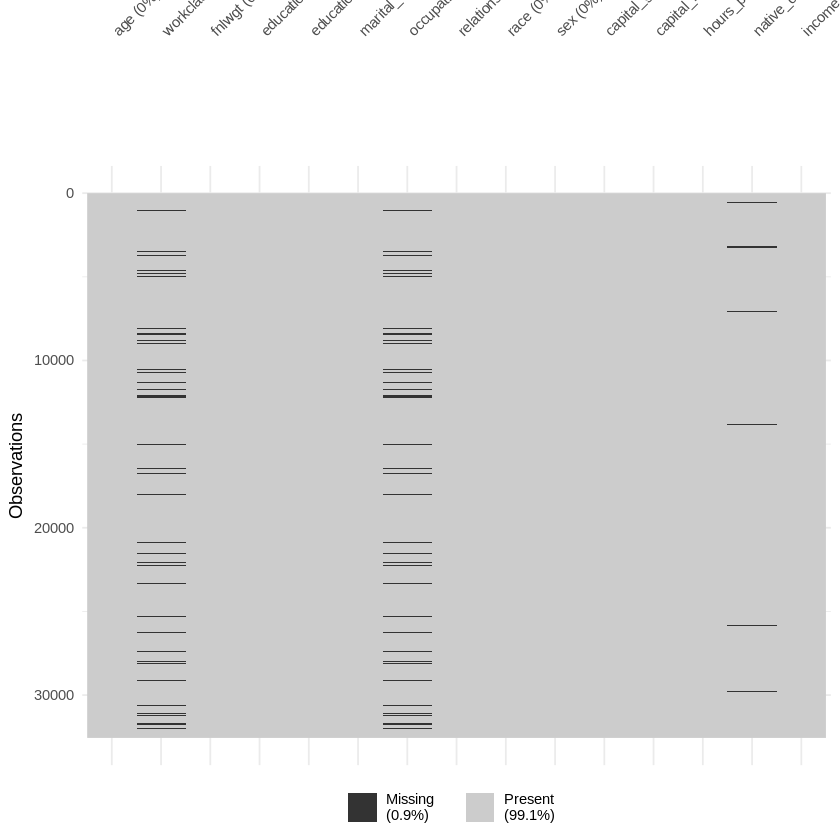

In [33]:
# Visualize missingness pattern
naniar::vis_miss(adult_data)


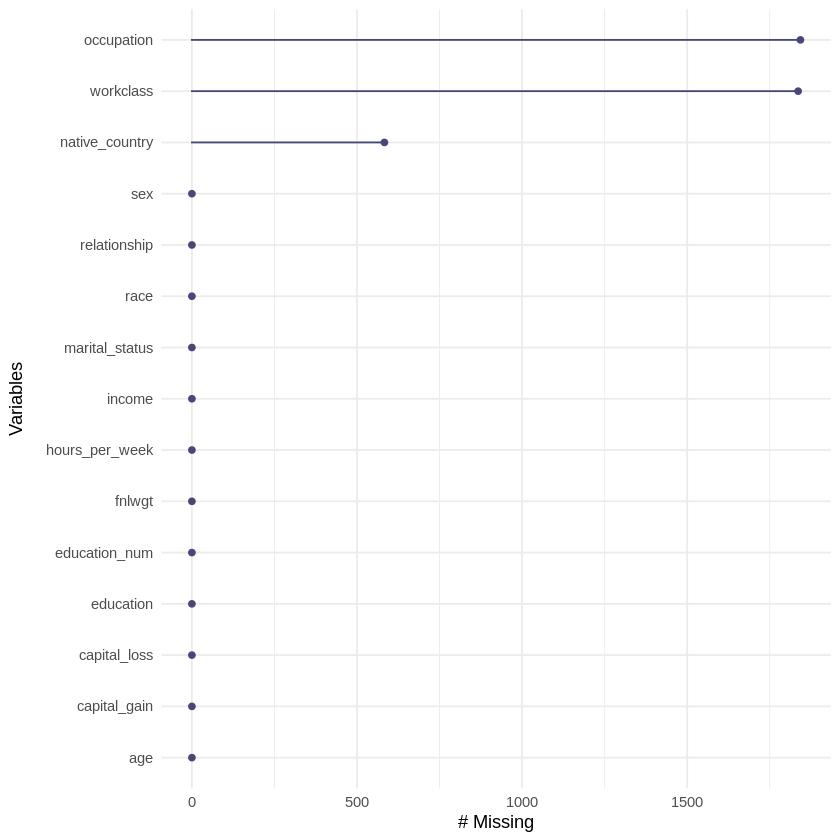

In [34]:
# Variable-wise missingness plot
naniar::gg_miss_var(adult_data)


### Comprehensive validation

In [35]:
skimr::skim(adult_data)


,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,1836,0.9436135,7,16,0,9,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1.0000000,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1.0000000,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,1843,0.9433985,5,17,0,15,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1.0000000,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1.0000000,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1.0000000,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,583,0.9820951,4,26,0,41,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1.0000000,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


### Final validation checks

In [36]:
# Verify impossible age values have been removed
cat("Age values equal to 999:", sum(adult_data$age == 999, na.rm = TRUE), "\n")

# Verify NaN values have been removed
cat("NaN values remaining:", sum(is.nan(adult_data$age)), "\n")

# Verify blank categorical values have been replaced
cat("Blank workclass values:", sum(adult_data$workclass == "", na.rm = TRUE), "\n")
cat("Blank occupation values:", sum(adult_data$occupation == "", na.rm = TRUE), "\n")

# Verify selected numeric variables contain no missing values
selected_numeric_missing <- sapply(
  adult_data[numeric_variables],
  function(x) sum(is.na(x) | is.nan(x))
)

selected_numeric_missing


Age values equal to 999: 0 
NaN values remaining: 0 
Blank workclass values: 0 
Blank occupation values: 0 


age         fnlwgt  education_num   capital_gain   capital_loss 
             0              0              0              0              0 
hours_per_week 
             0

In [37]:
# Final cleaned dataset preview
head(adult_data)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>
1,37,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,37,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,37,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Unknown,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Unknown,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [38]:
# Save cleaned Adult dataset
write.csv(
  adult_data,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

file.exists("cleaned_adult_data.csv")


[1] TRUE

## Part 2 Conclusion

The dataset was examined for `NA`, `NaN`, blank strings, and impossible age values. Invalid age values were converted to `NA`, blank categorical entries were replaced with `"Unknown"`, and missing numeric observations were imputed using the median through a reusable custom function. Missingness was summarized and visualized using `naniar`, and the final dataset was validated using `skimr::skim()` and explicit checks.
